In [1]:
%load_ext autoreload
%autoreload 2

## REMEMBER I NEED TO CHANGE THE NPX CHANNEL AND PATCH SAMPLING RATE FOR EACH CELL!!!! (when running the load functions for the first time)

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/shared_helper_modules'))

# General imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings

# NeuroDSP and FOOOF modules
from neurodsp import spectral
from fooof import FOOOF


# Custom modules
from lfp_spike_window_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, FILTER_SETTINGS


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/var/folders/rr/tk8wmt7x4xlgzgmcy768y1rm0000gn/T/ipykernel_87705/3622194312.py:20: DeprecationWarning: 
The `fooof` package is being deprecated and replaced by the `specparam` (spectral parameterization) package.
This version of `fooof` (1.1) is fully functional, but will not be further updated.
New projects are recommended to update to using `specparam` (see Changelog for details).
  from fooof import FOOOF


In [3]:
cell_num =42 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 2500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]

### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell 42  
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 42

## Step 0: Get loaded data #CHANGE DIRECTORIES FOR CELL DATA

In [4]:
lfp_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_lfp_recordings/c42_lfp_filt.npy'
patch_dir= '/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/Neuropixel Paired Recordings/Recordings/filt_patch_recordings/c42patch_filt.npy'


In [5]:
#get cell number 
cell_num = lfp_dir.split('/')[len(lfp_dir.split('/'))-1].split('_')[0]

#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

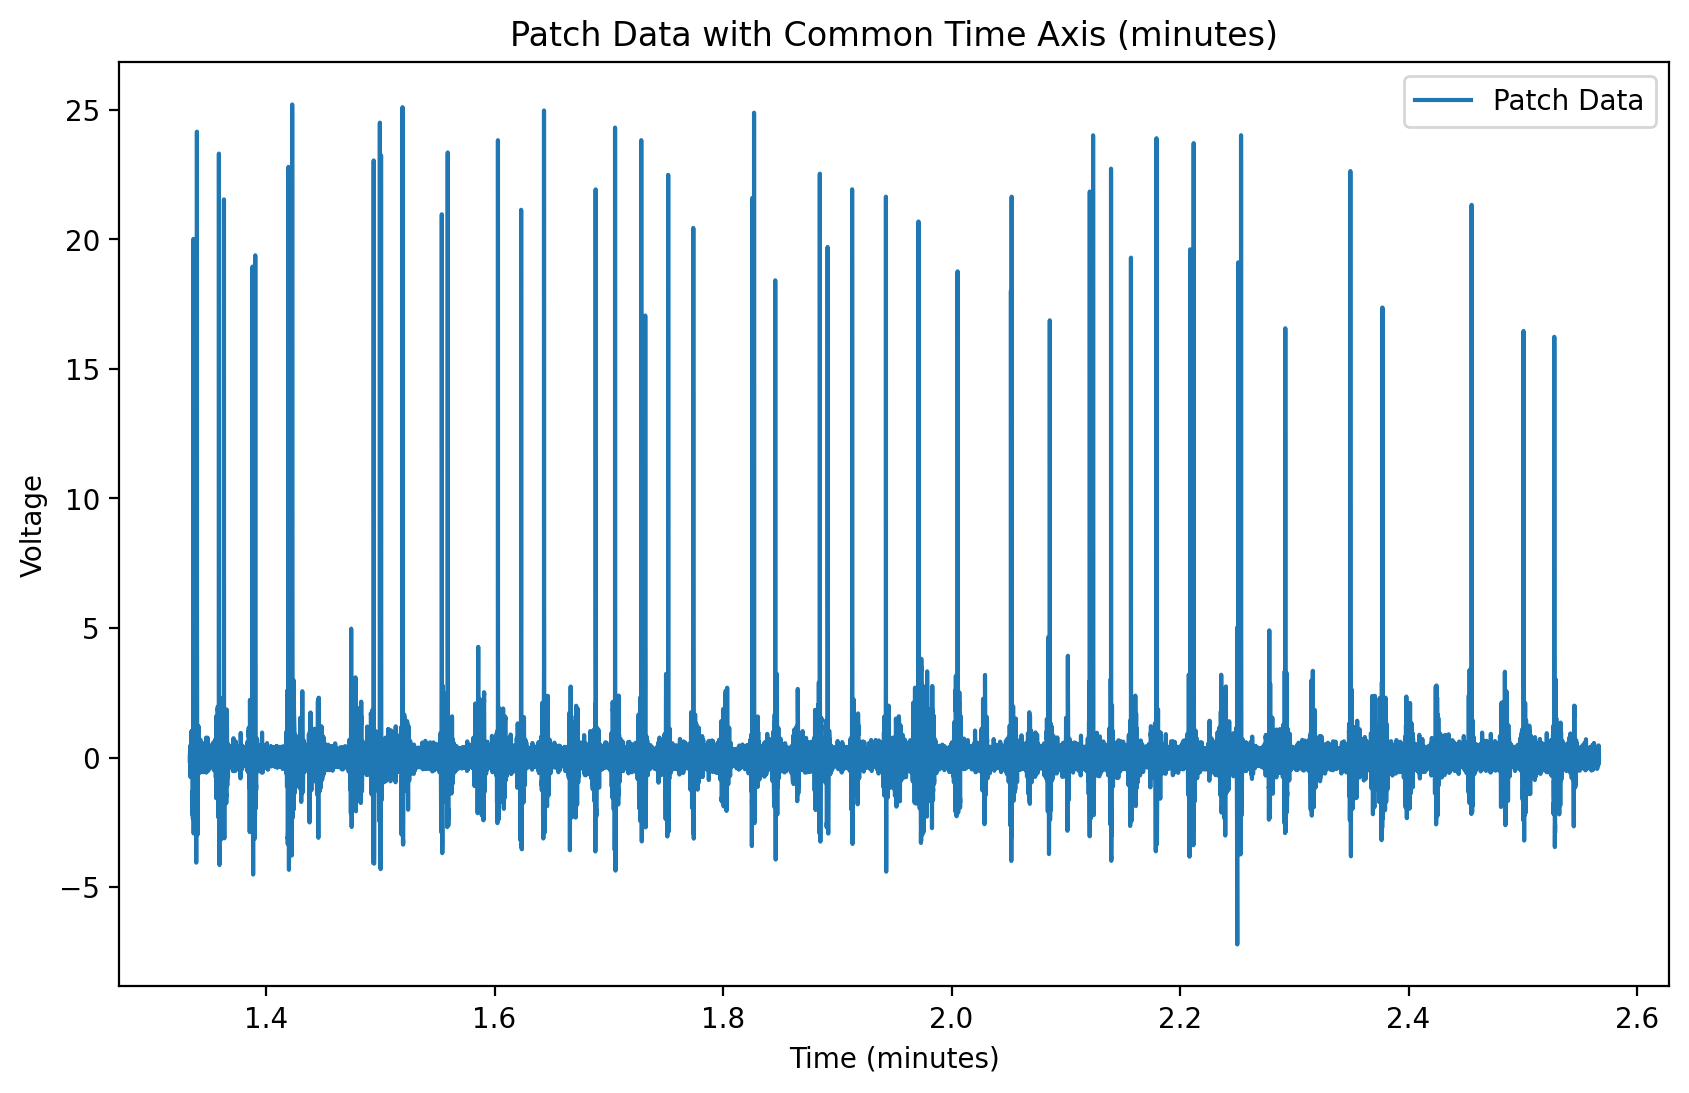

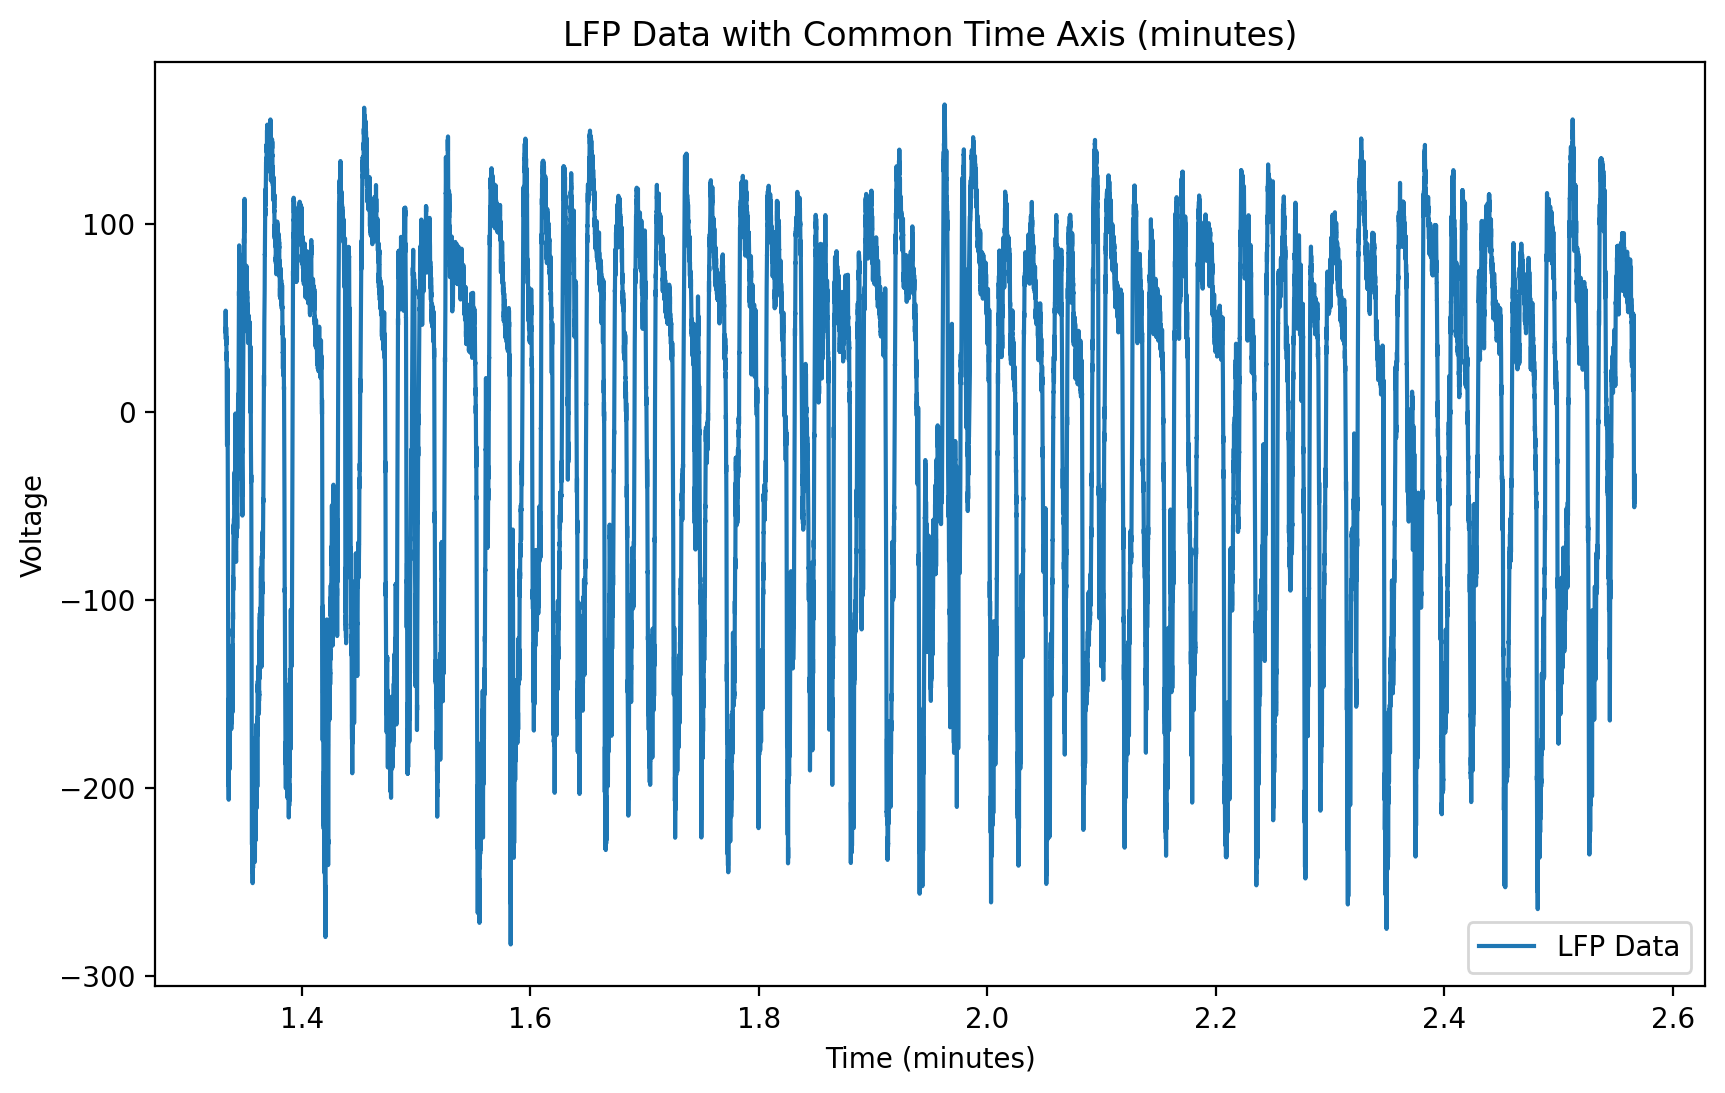

In [6]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 25.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: ANALYZE LFP DATA BY WINDOWS

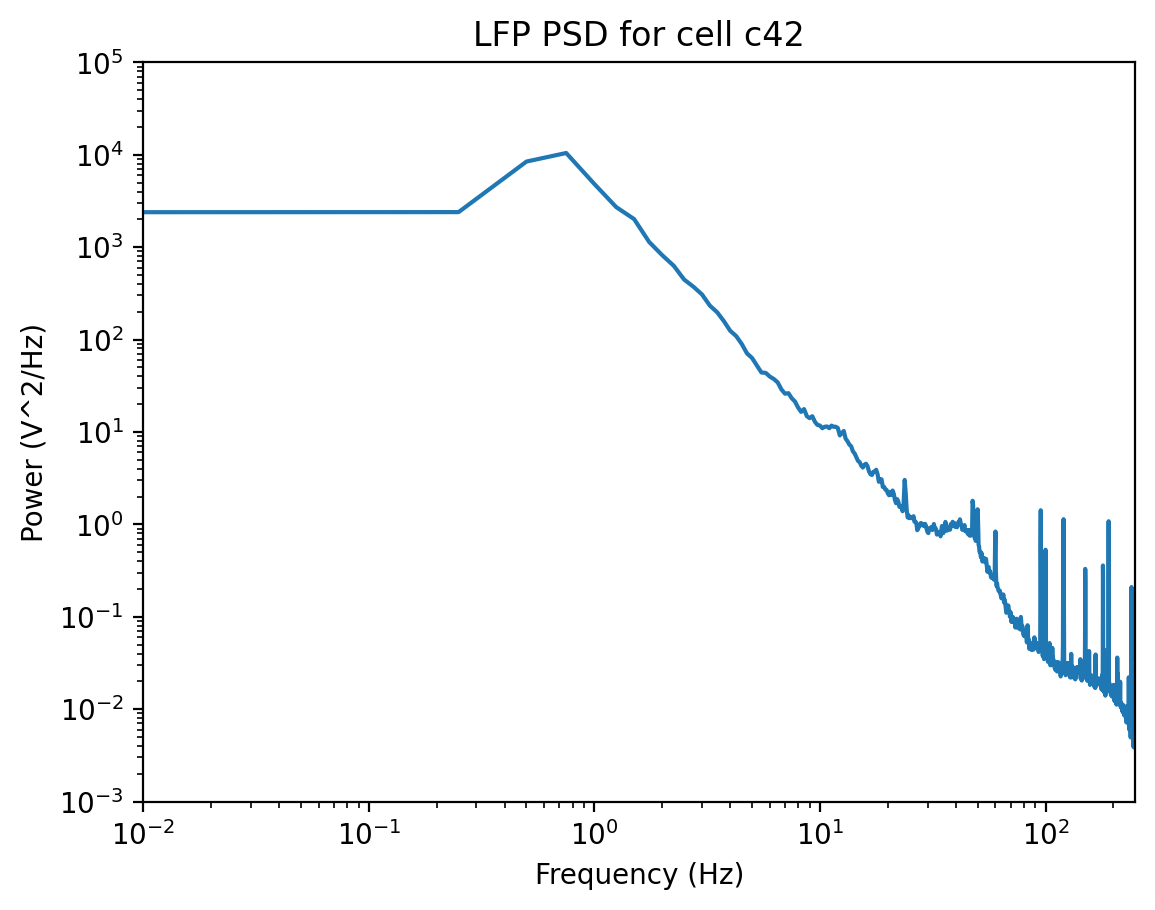

In [7]:
# plot power spectrum
fxx, pxx = spectral.compute_spectrum(lfp_filt, lfp_fs, method='welch', window='hann', nperseg=lfp_fs*4)

xlim = (10e-3, 250)
ylim = (10e-4, 10e4)
plt.loglog(fxx, pxx)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (V^2/Hz)')
plt.xlim(xlim)
plt.ylim(ylim)
plt.title("LFP PSD for cell "+ cell_num)
plt.show()


###### SLIDING WINDOWS APPROACH - Welch

In [8]:
spectra_welch, foof_results_welch, window_times_welch, summary_df_welch = compute_lfp_windows(
    lfp_signal=lfp_filt,
    fs=lfp_fs,
    method="welch"
)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


###### SLIDING WINDOWS APPROACH - Multitaper

/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/datasets/spe-1/spe1_helper_modules/lfp_spike_window_analysis.py:144: UserWarning: At least one of the wavelets (62501) is longer than the signal (62500). Consider using a longer signal or shorter wavelets.
  tfr = mne.time_frequency.tfr_array_multitaper(


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


/Users/blancamartin/opt/anaconda3/lib/python3.9/site-packages/fooof/plts/utils.py:42: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  _, ax = plt.subplots(figsize=figsize)


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


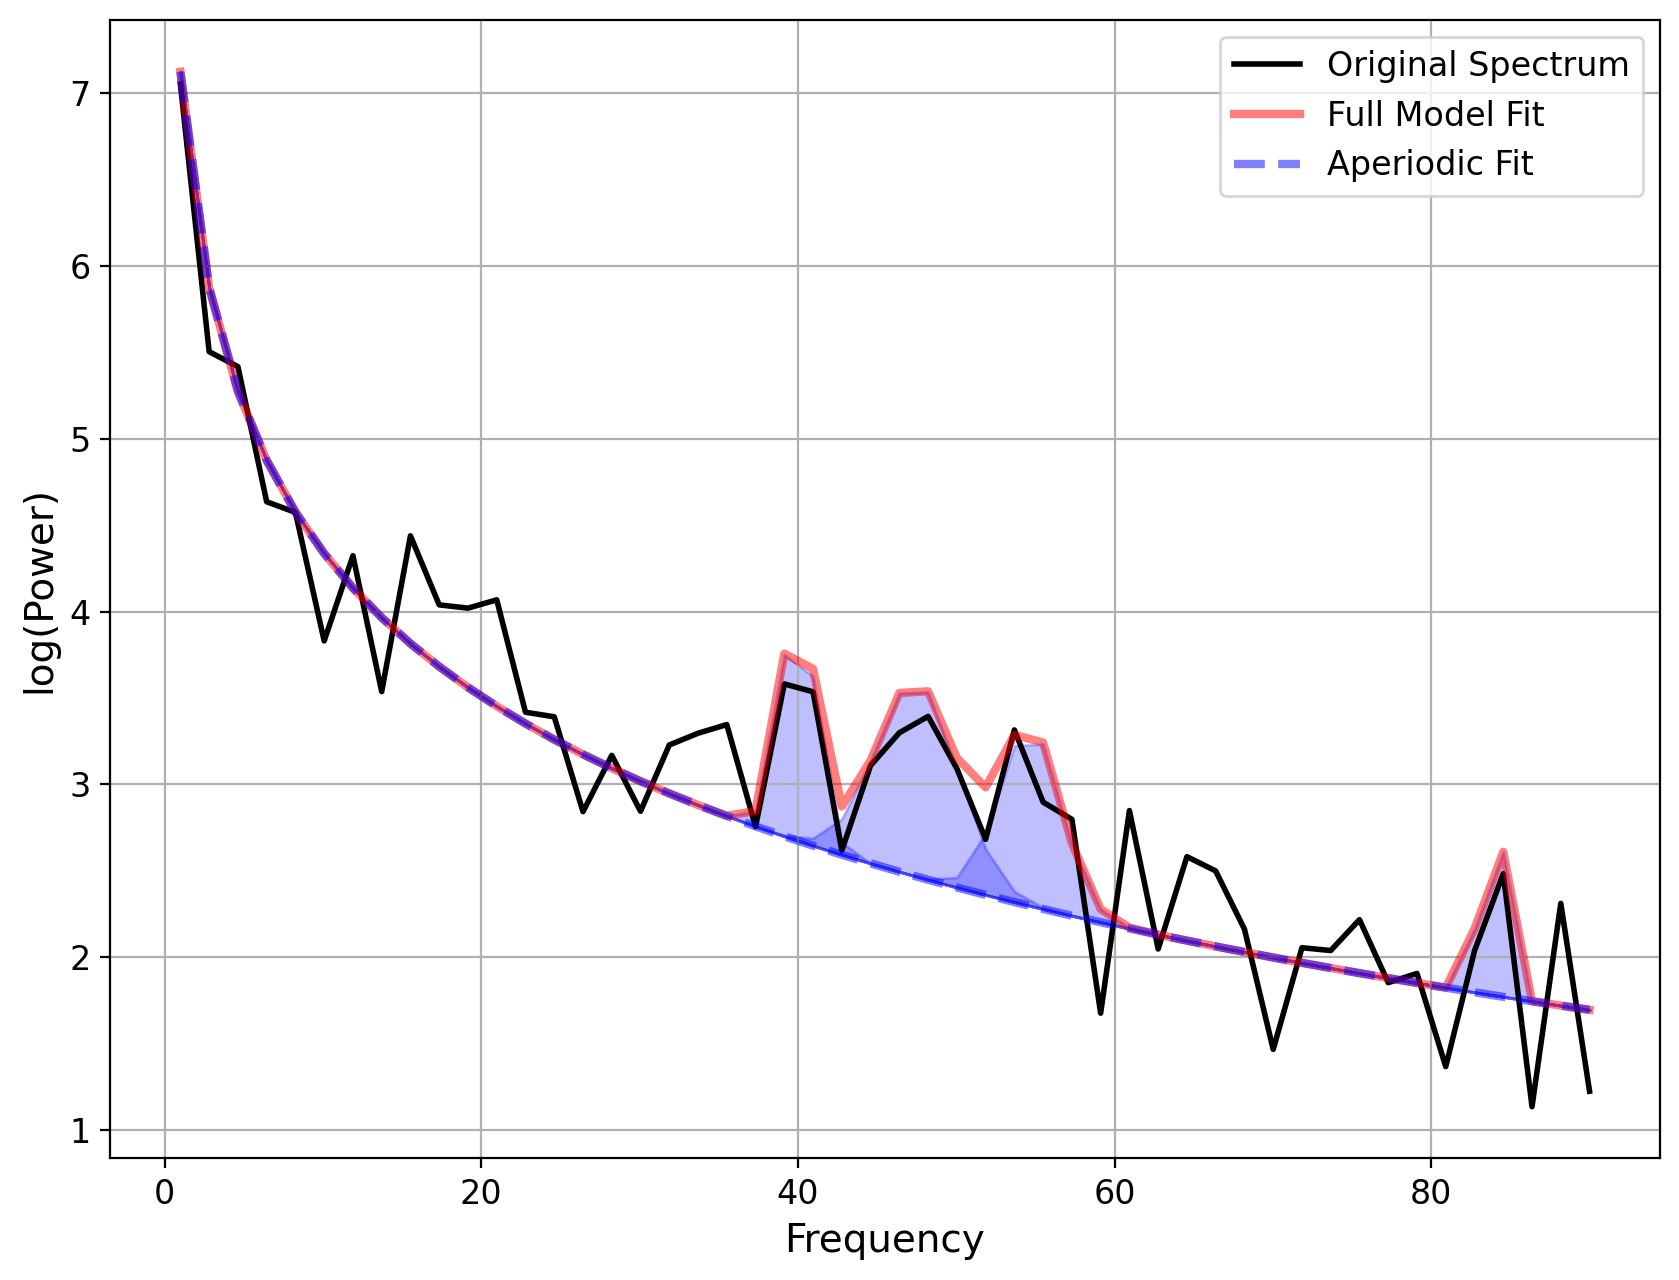

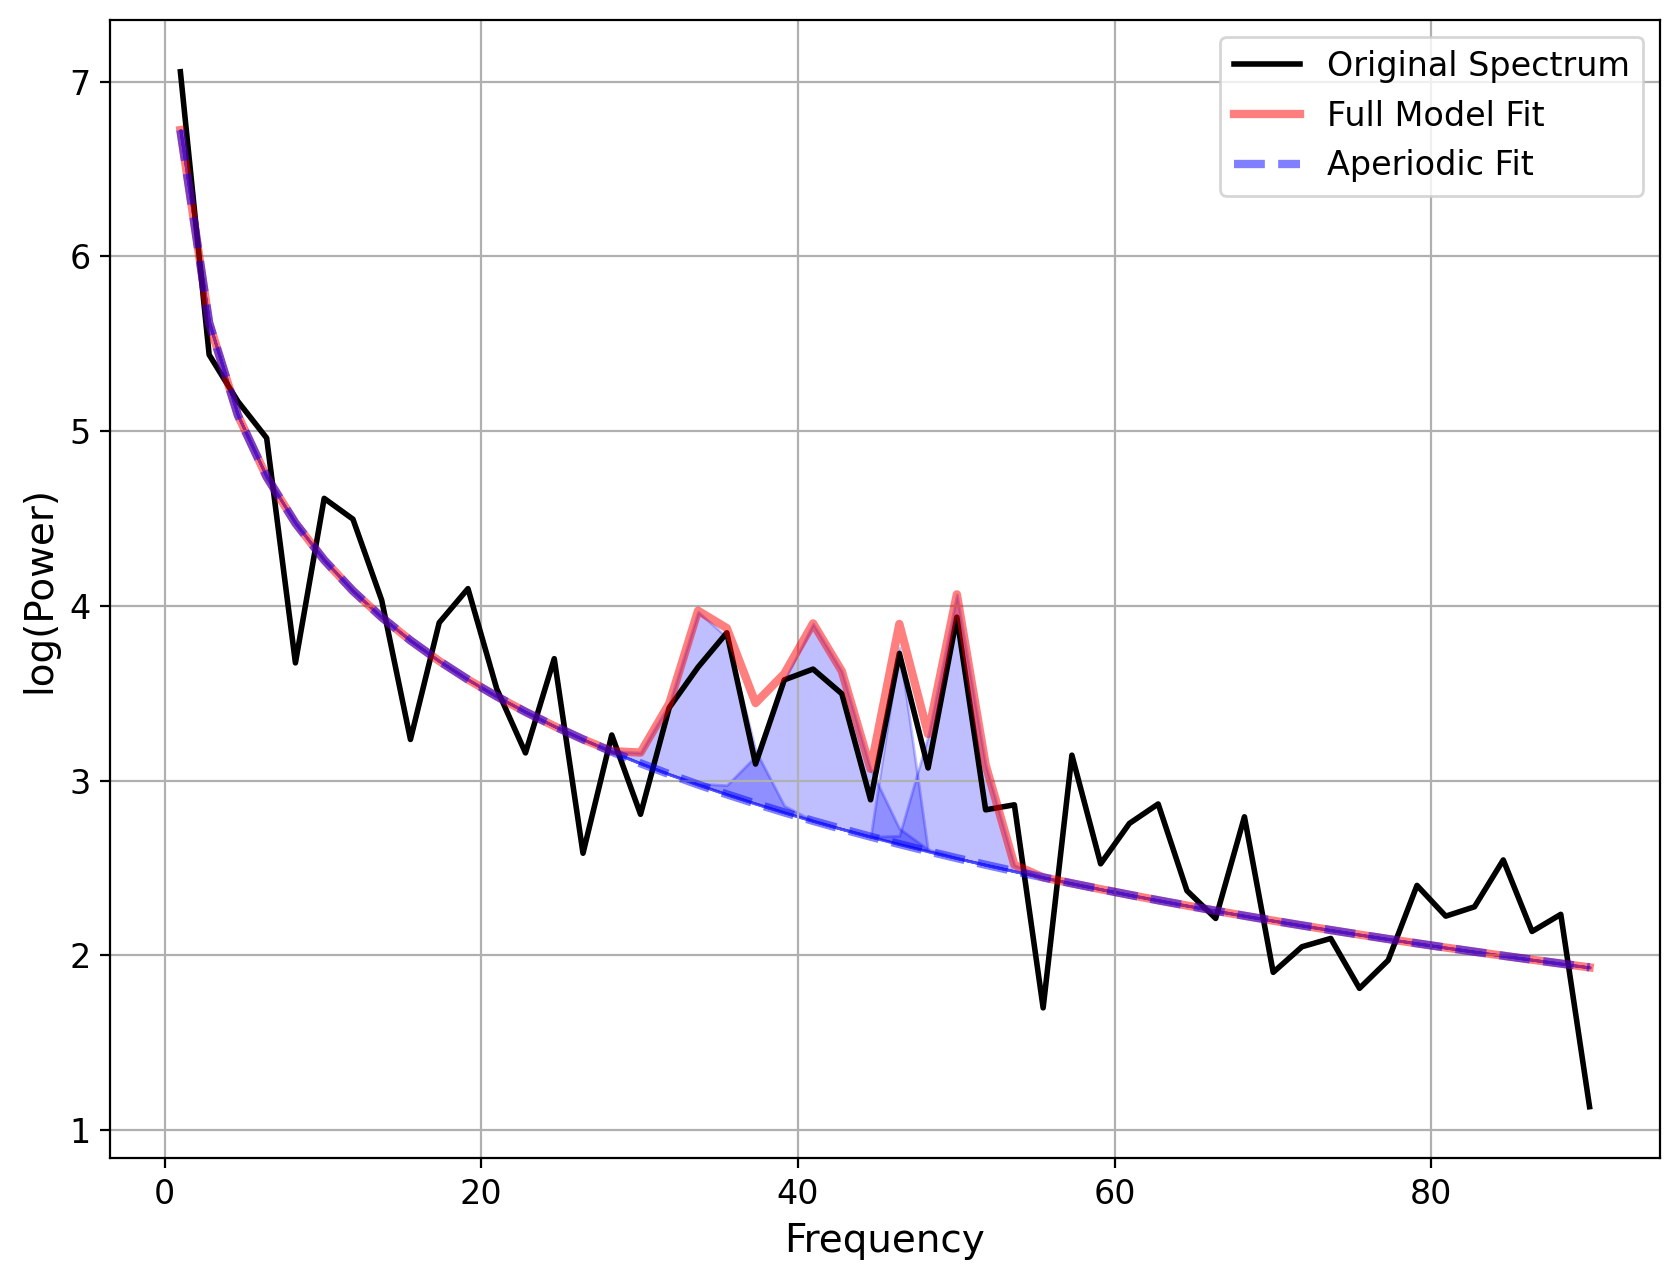

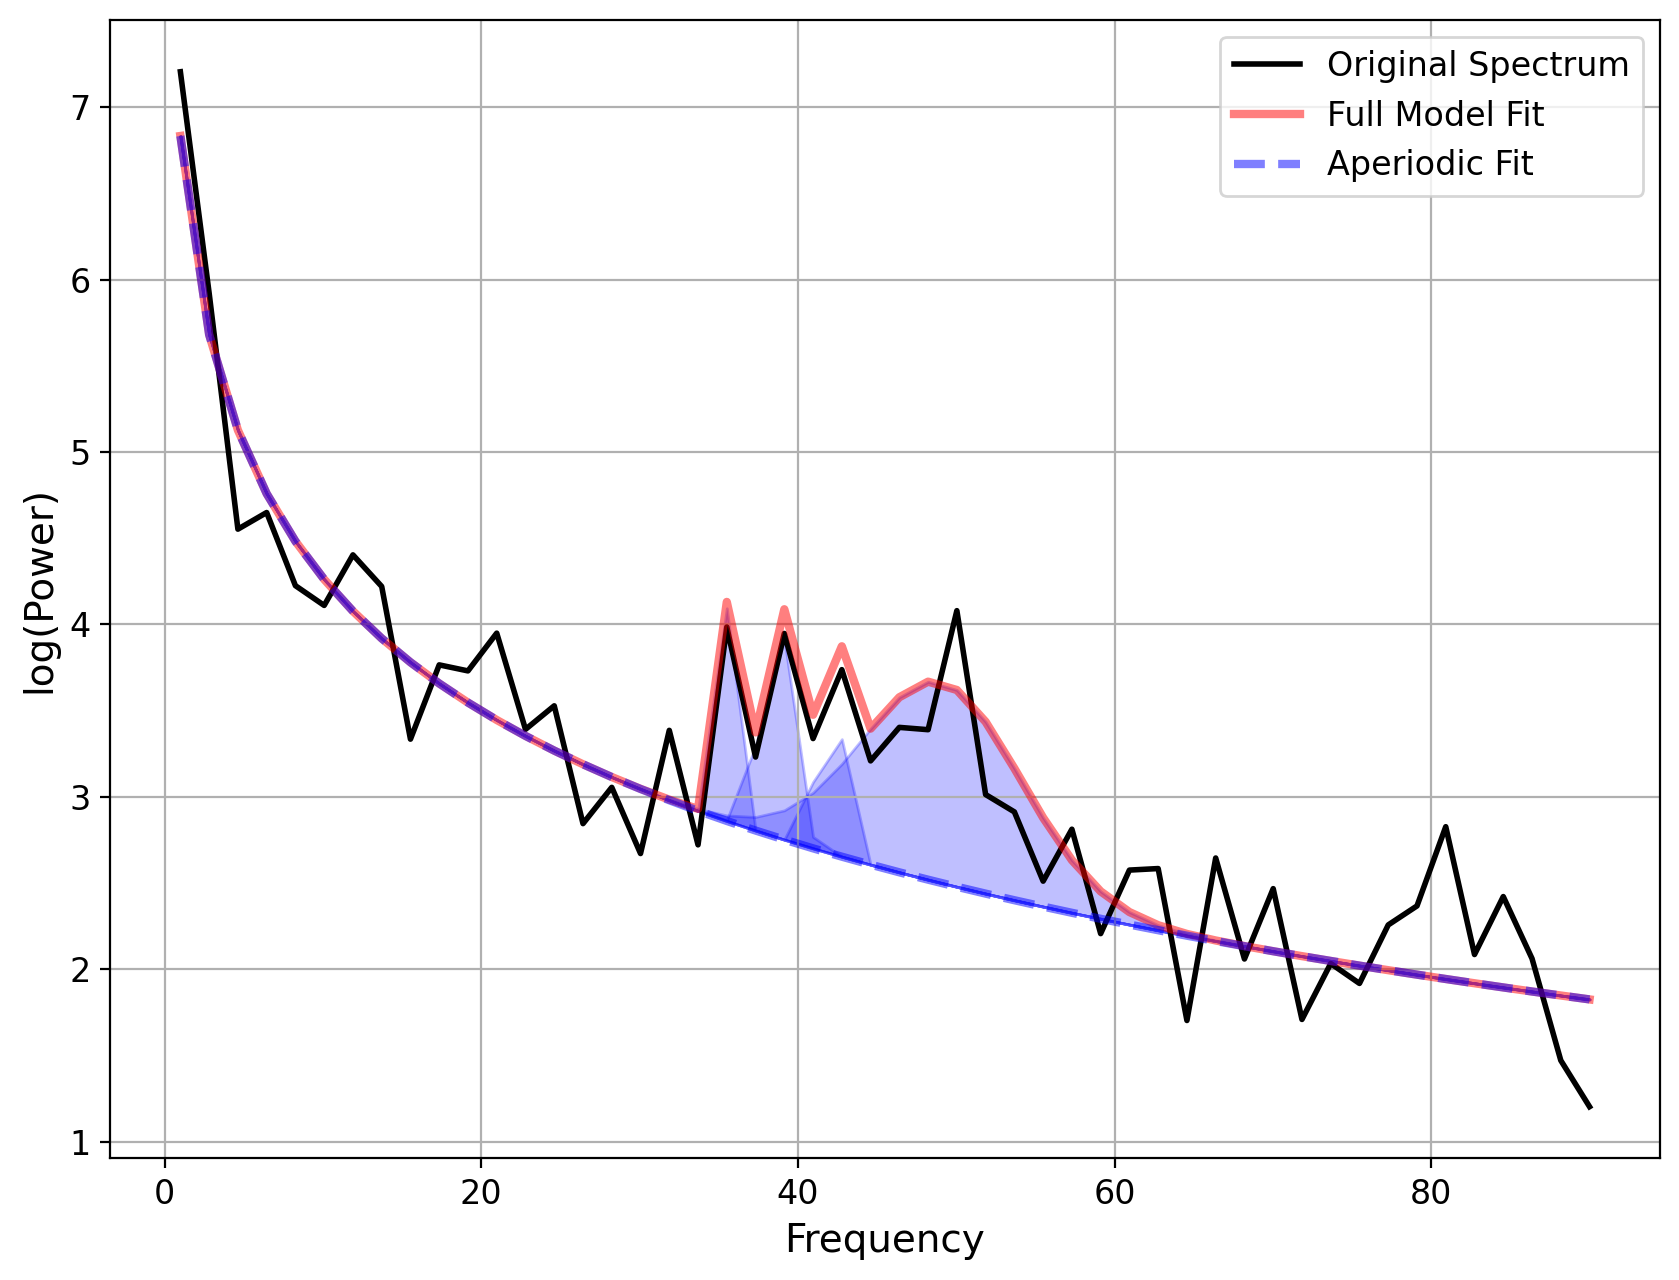

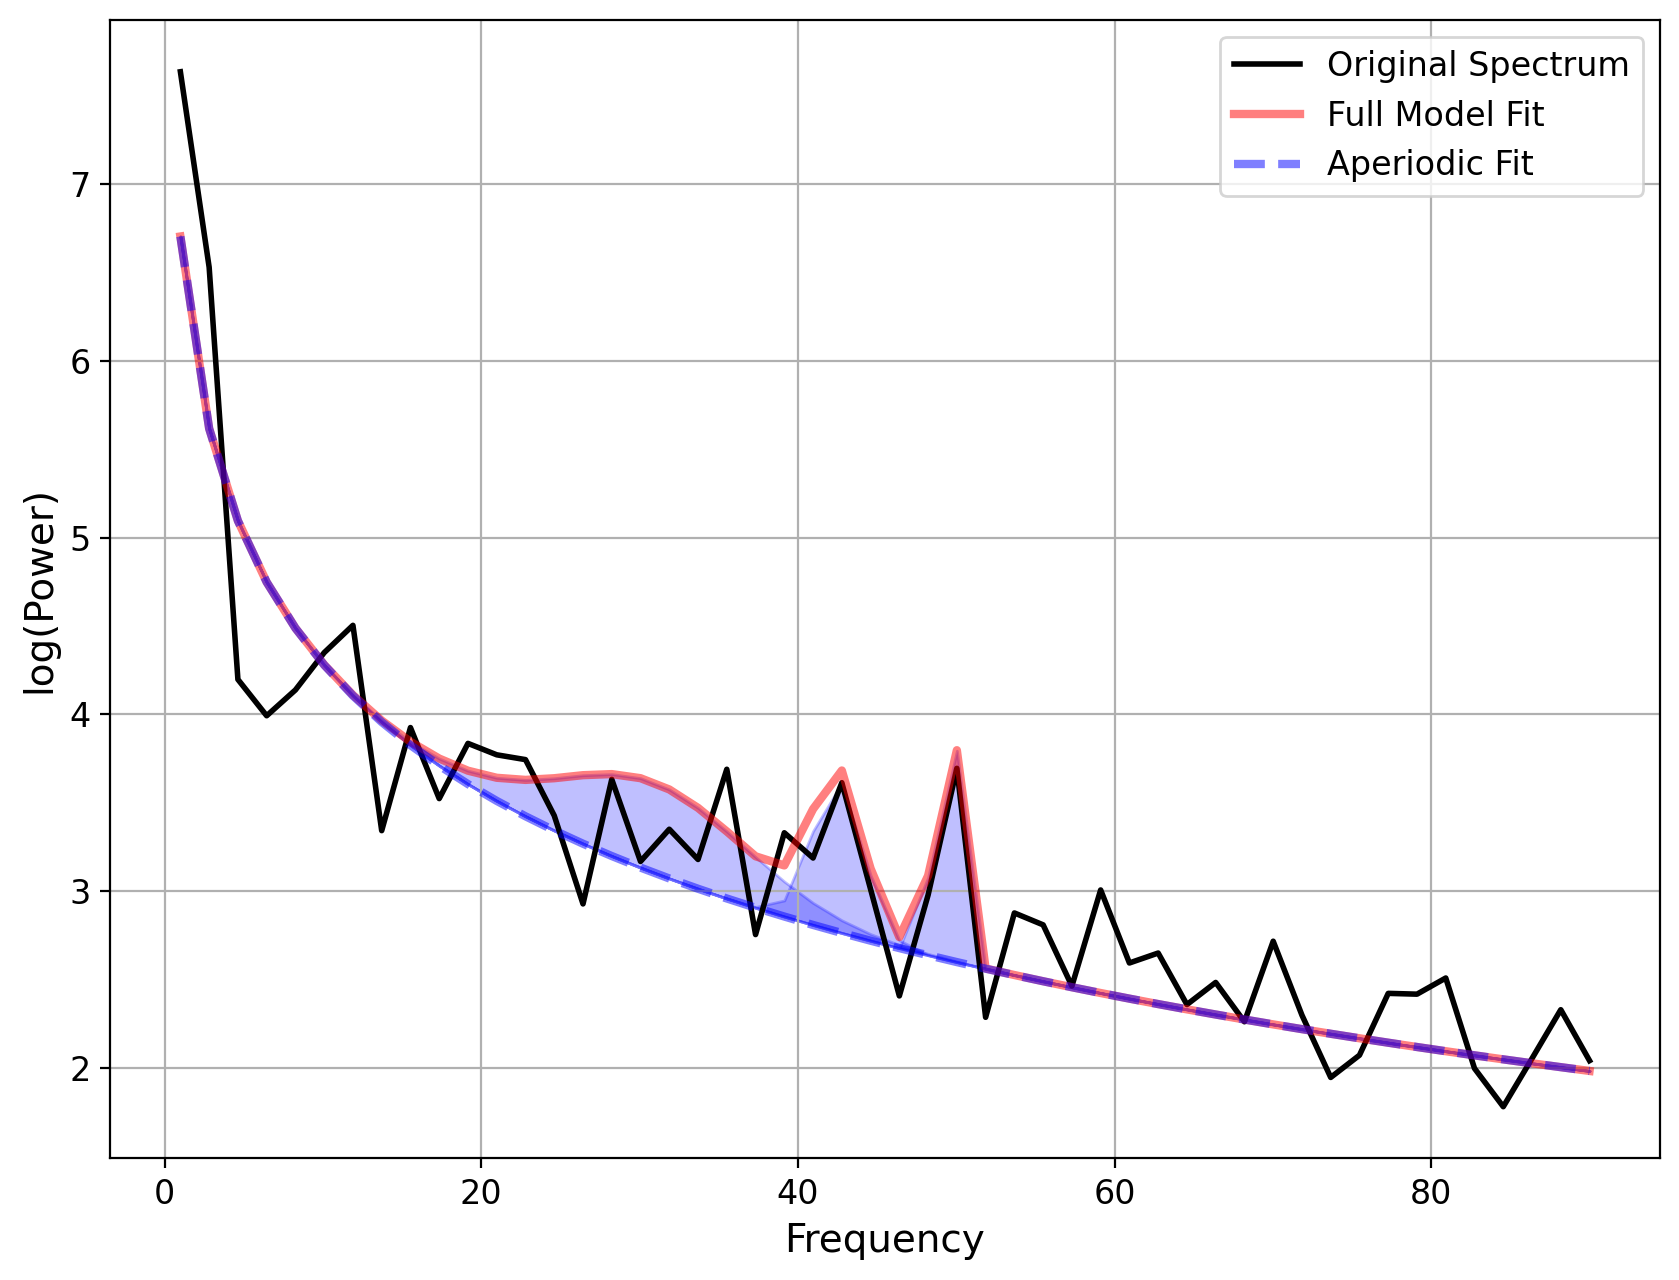

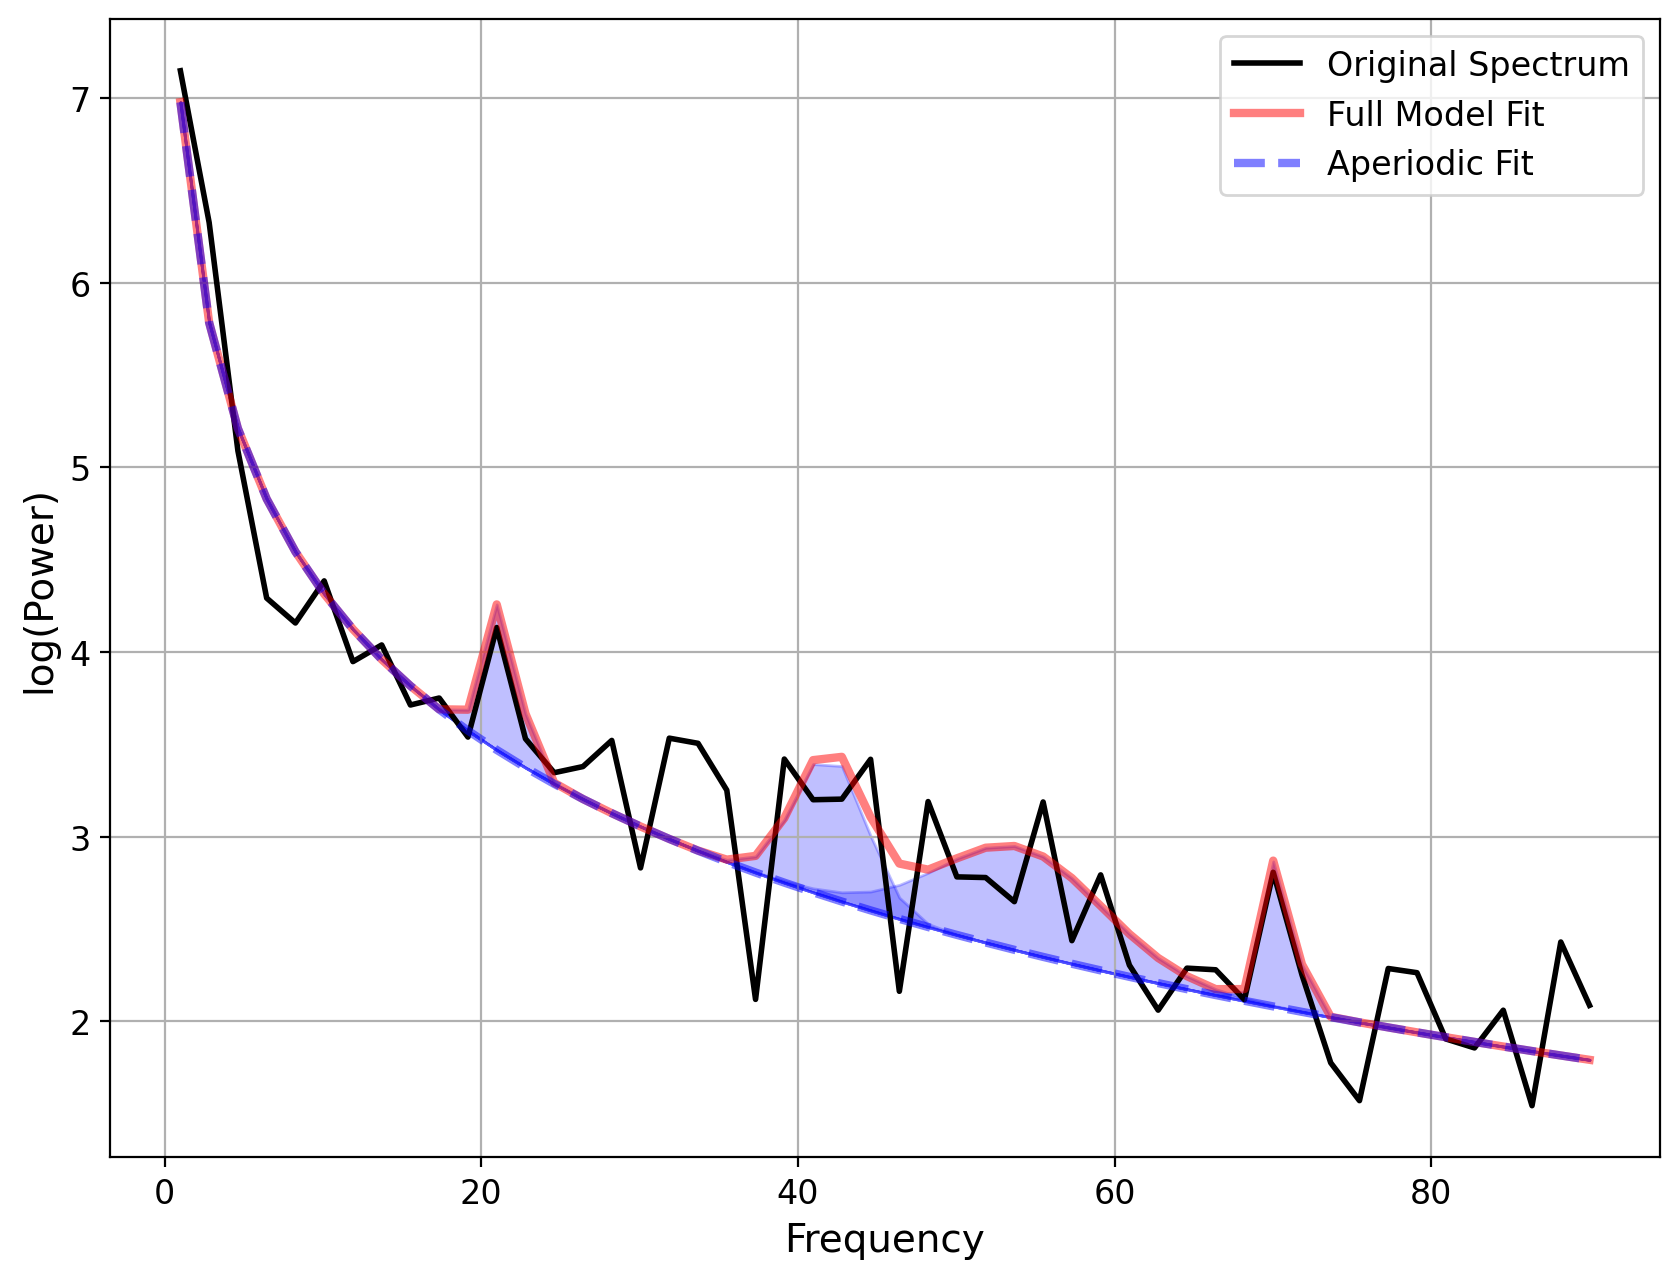

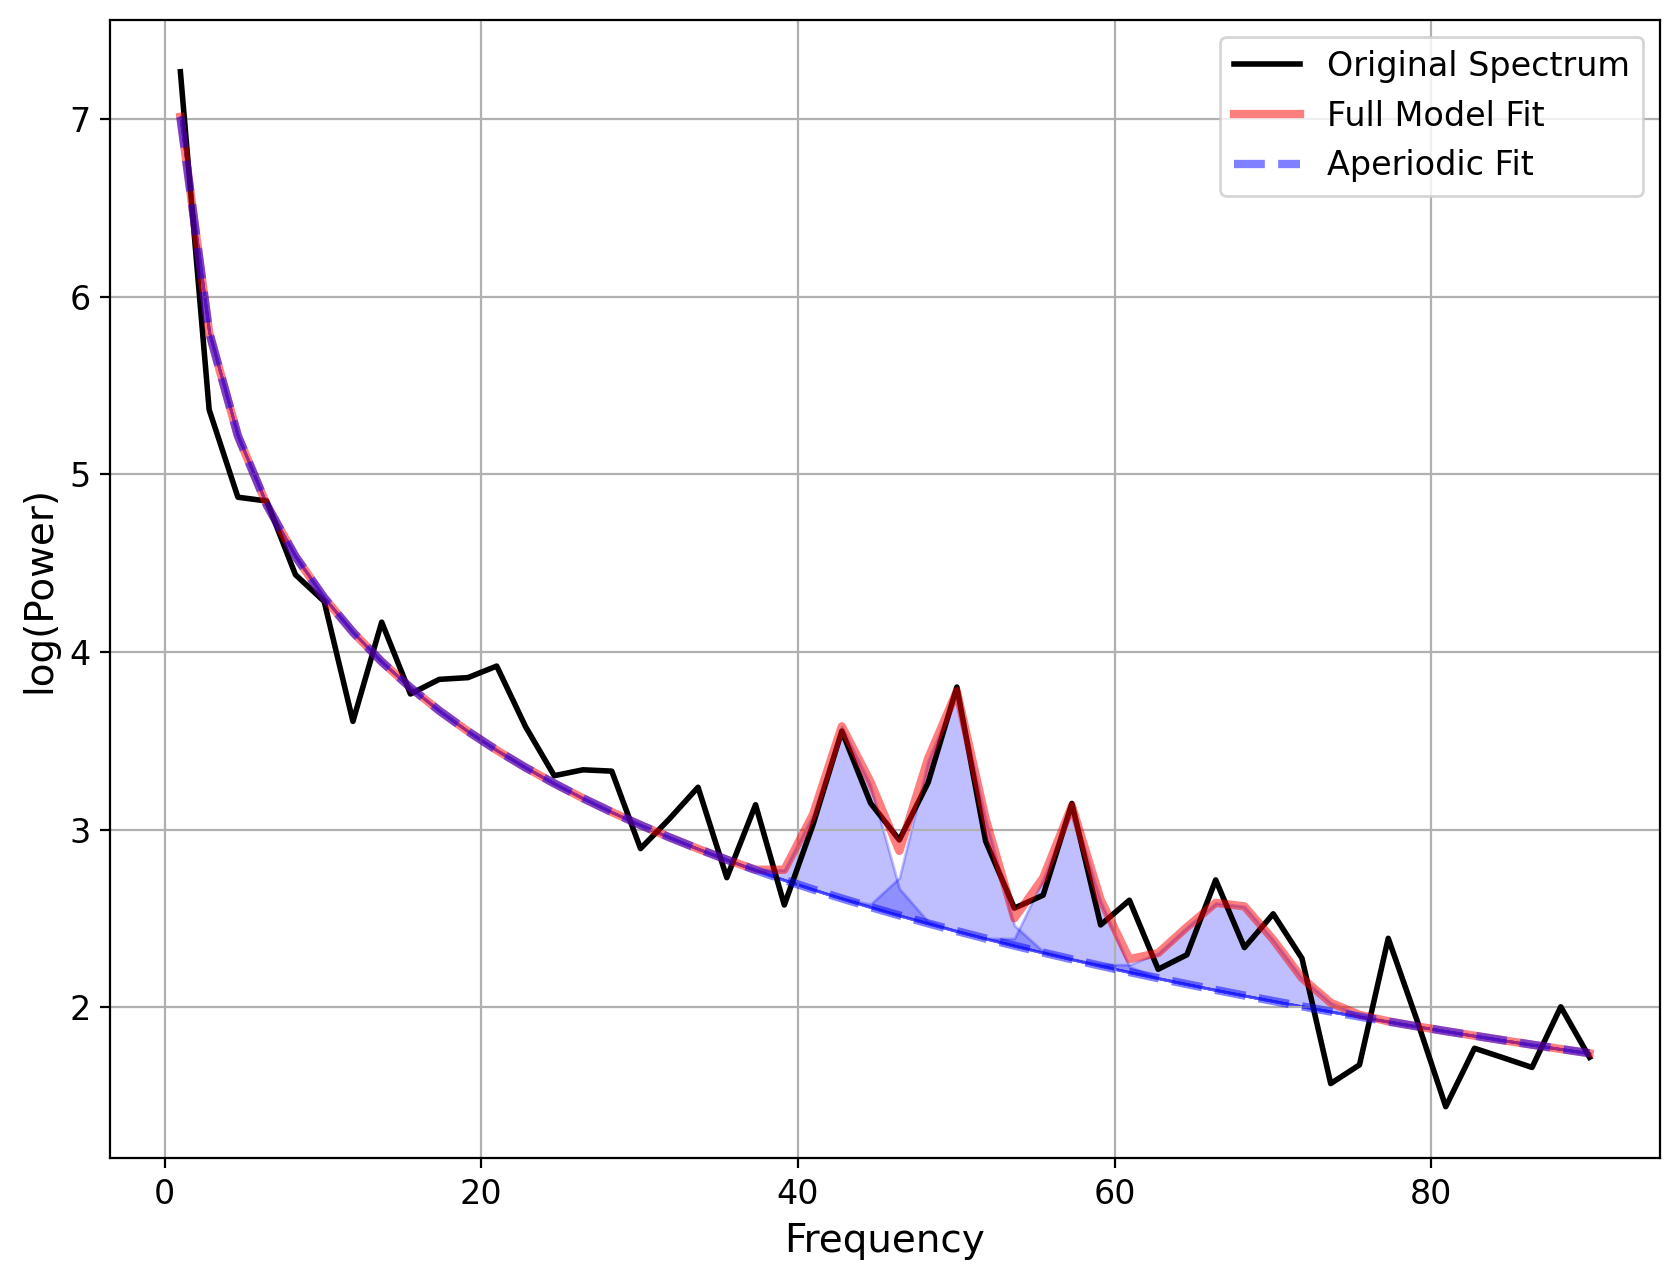

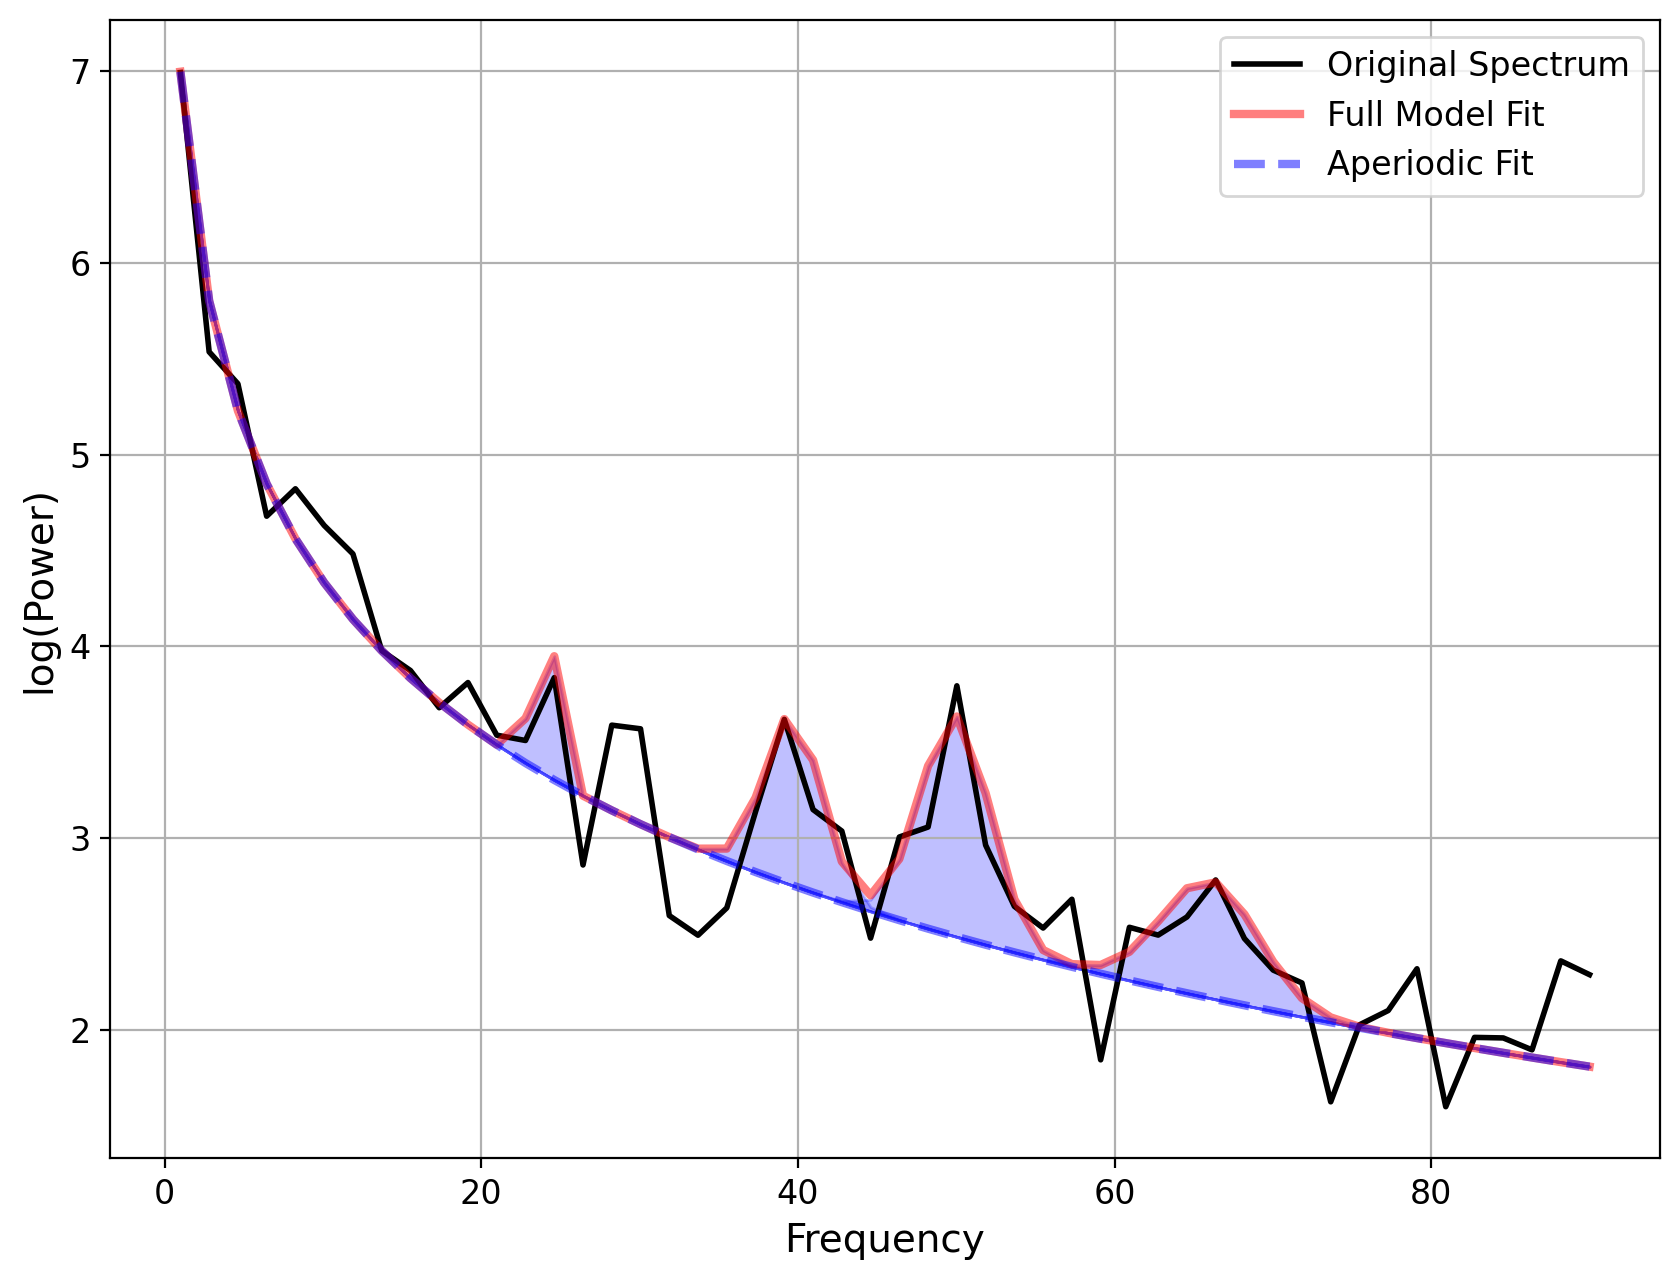

In [ ]:
spectra_multitaper, foof_results_multitaper, window_times_multitaper, summary_df_multitaper = compute_lfp_windows(
    lfp_signal=lfp_filt, fs=lfp_fs, method="multitaper", plot = True
)


## STEP 2: Detect spikes from patch data

In [ ]:
plt.plot(patch_filt[:100000] )

In [ ]:



#threshold in mVs
sp = Spike(thresh_amp=10, window_length=(5., 5.), smooth_frac=.01)

In [ ]:

sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm)

### Filter spikes 

In [ ]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [ ]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [ ]:
df_features

### Get spike times


In [ ]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

## STEP 3: Align spikes to lfp windows

In [ ]:
spike_to_window_map = map_spikes_to_windows(spk_times_ms, spk_ids, window_times_welch, df_features['spk_id'], lfp_fs)


### Visualize spikes and lfp windows 

In [ ]:
plot_spike_time_histogram(spk_times_ms,
    window_times_multitaper,
    lfp_fs)



## STEP 4: COMBINE SPIKE DATAFRAME WITH LFP FEATURES (FOR CURRENT WINDOW AND PREVIOUS WINDOW)

In [ ]:

df_combined_spk_lfp_welch = combine_spike_lfp_features(
    spike_data=df_features,
    foof_results=foof_results_welch,
    spike_to_window_map=spike_to_window_map
)
df_combined_spk_lfp_multit = combine_spike_lfp_features(
    spike_data=df_features,
    foof_results=foof_results_multitaper,
    spike_to_window_map=spike_to_window_map
)


In [ ]:
df_combined_spk_lfp_welch[:3000]


In [ ]:
df_combined_spk_lfp_multit[:3000]

### STEP 5: ANALYZE IF SPIKE WAVEFORM FEATURES CHANGE BASED ON CURRENT AND PREVIOUS LFP WINDOW - CORRELATIONS

In [ ]:
# Define spike and LFP features
spike_features = ['ramp_amp', 'inflection_time', 'inflection_amp','peak_amp', 'peak_width', 'peak_sharpness','exp_lambda', 	'exp_const', 'log_isi']
lfp_features_current_mean = [
    'lfp_current_offset_mean',
    'lfp_current_exponent_mean',
    'lfp_current_r_squared_mean',
    'lfp_current_n_peaks_mean'
]
lfp_features_previous_mean = [
    'lfp_previous_offset_mean',
    'lfp_previous_exponent_mean',
    'lfp_previous_r_squared_mean',
    'lfp_previous_n_peaks_mean'
]

In [ ]:
df_current_lfp_processed_welch = compute_lfp_feature_means(
    df=df_combined_spk_lfp_welch,
    lfp_type="current",
    drop_irrelevant=True,  # Drop previous LFP features
    drop_original=True,    # Drop original current LFP list columns
)
df_previous_lfp_processed_welch = compute_lfp_feature_means(
    df=df_combined_spk_lfp_welch,
    lfp_type="previous",
    drop_irrelevant=True,  # Drop current LFP features
    drop_original=True,    # Drop original previous LFP list columns
)

df_current_lfp_processed_multit = compute_lfp_feature_means(
    df=df_combined_spk_lfp_multit,
    lfp_type="current",
    drop_irrelevant=True,  # Drop previous LFP features
    drop_original=True,    # Drop original current LFP list columns
)
df_previous_lfp_processed_multit = compute_lfp_feature_means(
    df=df_combined_spk_lfp_multit,
    lfp_type="previous",
    drop_irrelevant=True,  # Drop current LFP features
    drop_original=True,    # Drop original previous LFP list columns
)

In [ ]:
plot_lfp_spk_correlation_heatmap(
    df_current_lfp_processed_welch,
    spike_features,
    lfp_features_current_mean, title = "Correlation heatmap Welch current LFP window")
plot_lfp_spk_correlation_heatmap(
    df_previous_lfp_processed_welch,
    spike_features,
    lfp_features_previous_mean, title = "Correlation heatmap Welch previous LFP window")



In [ ]:
plot_lfp_spk_correlation_heatmap(
    df_current_lfp_processed_multit,
    spike_features,
    lfp_features_current_mean,  title = "Correlation heatmap Multitaper current LFP window")
plot_lfp_spk_correlation_heatmap(
    df_previous_lfp_processed_multit,
    spike_features,
    lfp_features_previous_mean,  title = "Correlation heatmap Multitaper current LFP window")



### STEP 6: ANALYZE IF SPIKE WAVEFORM FEATURES CHANGE BASED ON CURRENT AND PREVIOUS LFP WINDOW - 

In [ ]:
import statsmodels.api as sm
from IPython.display import display

# Create a DataFrame to store regression results
results = []

# Loop through each spike parameter
for spike_param in spike_features:
    X = df_current_lfp_processed[lfp_features]
    X = sm.add_constant(X)  # Add intercept
    y = df_current_lfp_processed[spike_param]
    
    # Fit the model
    model = sm.OLS(y, X).fit()
    
    # Extract p-values and coefficients for LFP features
    for lfp_param in lfp_features:
        coef = model.params[lfp_param]
        p_value = model.pvalues[lfp_param]
        results.append({
            'Spike Parameter': spike_param,
            'LFP Parameter': lfp_param,
            'Coefficient': coef,
            'p-value': p_value
        })

# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Display significant results (p < 0.05)
significant_results = results_df[results_df['p-value'] < 0.05]
print("Significant Relationships (p < 0.05):")
display(significant_results)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_corr_heatmap_with_stars(df):
    # Calculate correlation matrix
    corr = df.corr()

    # Compute p-values
    pval = df.corr(method=lambda x, y: pearsonr(x, y)[1]) - np.eye(len(df.columns))

    # Convert p-values to stars
    def p_to_star(p):
        if p < 0.001: return '***'
        elif p < 0.01: return '**'
        elif p < 0.05: return '*'
        else: return ''

    stars = pval.applymap(p_to_star)

    # Combine correlation and stars into annotation matrix
    annot = corr.round(2).astype(str) + stars

    # Force to NumPy array (important!)
    annot = annot.values

    # Plot
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=annot, fmt="", cmap='coolwarm', center=0,
                linewidths=0.5, annot_kws={"size": 12})
    plt.title("Correlation Heatmap with Significance Stars")
    plt.tight_layout()
    plt.show()

# Example Data
np.random.seed(1)
data = np.random.randn(100, 5)
df_test = pd.DataFrame(data, columns=["feat1", "feat2", "feat3", "feat4", "feat5"])

plot_corr_heatmap_with_stars(df_test)
